In [1]:
# Import the libraries and split modules used by the main notebook
# matplotlib: display intermediate and final figures
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import warnings
import time
import os
from datetime import datetime
from pathlib import Path
from IPython.display import display

from forward_module import Physics_deepwave, SurveyConfig, simulate_observed_data
from functions_module import (
    adjest_deepwave,
    get_dir,
    load_velocity_model,
    save_run_parameters,
    seed_everything,
    train_deepwave,
    weights_init,
)
from network_module import SiameseNetwork, Transfomerdecoder

warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


In [2]:
# Cell 2: Check the PyTorch and CUDA environment
# This confirms whether the notebook can use the GPU

print('PyTorch version: ', torch.__version__)
print('CUDA available: ', torch.cuda.is_available())


PyTorch version:  2.5.1+cu121
CUDA available:  True


In [3]:
# Select the execution device
# Use cuda:0 if a GPU is available, otherwise use the CPU

gpu_count = torch.cuda.device_count()
print(f'The number of available GPUs is: {gpu_count}')
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f'The selected GPU device is: {torch.cuda.get_device_name(device)}')
else:
    device = torch.device('cpu')
    print('No available GPUs detected, switched to using CPU')


The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


In [4]:
#  Fix the random seed
# This helps keep initialization and training behavior reproducible

seed_everything(43)


In [5]:
#  Define the helper used to display and save model figures during training
# It is called every SAVE_FREQ iterations to both save and show the current model

def show_result_figure(m, title, save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(m.detach().cpu().T, cmap='jet', vmin=m.min(), vmax=m.max())
    points = ax.get_position().get_points()
    dy = points[1, 1] - points[0, 1]
    cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
    cax.yaxis.set_ticks_position('right')
    fig.colorbar(im, cax=cax, orientation='vertical', extend='neither', label='$V_P (m/s)$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    display(fig)
    plt.close(fig)


In [6]:
# Set file paths, forward parameters, network parameters, and run parameters
# Variable names stay close to the original PIT_FWI.ipynb for easier comparison

'''File_path'''
base_dir = Path.cwd()
True_model_Path = base_dir / 'data' / 'sig2.dat'
Init_model_Path = base_dir / 'data' / 'sigsbee_init_100'

'''Ture_model'''
survey_cfg = SurveyConfig()
vp_true = load_velocity_model(True_model_Path, (201, 225), device)

'''Init_model'''
vp_initial = load_velocity_model(Init_model_Path, (201, 225), device)
vp_initial.requires_grad = True
vp_initial = torch.nn.Parameter(vp_initial)

'''Forward parameters'''
ny = 201
nx = 225
dx = survey_cfg.dx
n_shots = survey_cfg.n_shots
n_sources_per_shot = survey_cfg.n_sources_per_shot
d_source = survey_cfg.d_source
first_source = survey_cfg.first_source
source_depth = survey_cfg.source_depth
n_receivers_per_shot = survey_cfg.n_receivers_per_shot
dz_receiver = survey_cfg.dz_receiver
receiver_depth_start = survey_cfg.receiver_depth_start
freq = survey_cfg.freq
dt = survey_cfg.dt
nt = survey_cfg.nt
peak_time = survey_cfg.peak_time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

'''Network parameters'''
leak_value = 0.00001
D1 = 1

model_shape = [ny, nx]
BATCH_SIZE = 1
N_SHOTS = n_shots
NT = nt
N_RECEIVERS = n_receivers_per_shot
FINAL_OUT_CHANNEL = 1
N_BLOCKS_DECODER = 4
NUM_HEADS = 2
MPL_RATION = 4.0
PATCH_SIZE = (100, 100)
EMBED_DIM = 12
TRANSDDEPTH = 12
DECODER_INITIAL_SHAPE = torch.div(torch.tensor(model_shape), (2 ** (N_BLOCKS_DECODER - 1)), rounding_mode='floor')
FINAL_SIZE_ENCODER = int(BATCH_SIZE * DECODER_INITIAL_SHAPE[0] * DECODER_INITIAL_SHAPE[1])

Physics = Physics_deepwave
train_fun = train_deepwave
adjest_fun = adjest_deepwave

'''Run parameters'''
vp_scale = 1
LR_MILESTONE = 500
ITERATION = 2000
lr = 0.004
MINI_BATCHES = n_shots
LAM_PRIOR = 0.0
PRINT_FREQ = 1
SAVE_FREQ = 50

'''adjest parameters'''
fwi_lr = 3
fwi_batch = n_shots
fwi_num_epochs = 0
sim_lr = 1 * 1e-3

'''Save_record_path'''
current_time = datetime.now().strftime('%Y%m%d_%H%M%S')
Path = Path(get_dir(base_dir / 'result' / 'VIT' / f'over_{nx}_{ny}' / f'results_{current_time}'))


In [7]:
#Print the shapes of the true model and the initial model
# This is a quick check that the data was loaded correctly

print(f'vp_true shape is {vp_true.shape}')
print(f'vp_initial shape is {vp_initial.shape}')


vp_true shape is torch.Size([201, 225])
vp_initial shape is torch.Size([201, 225])


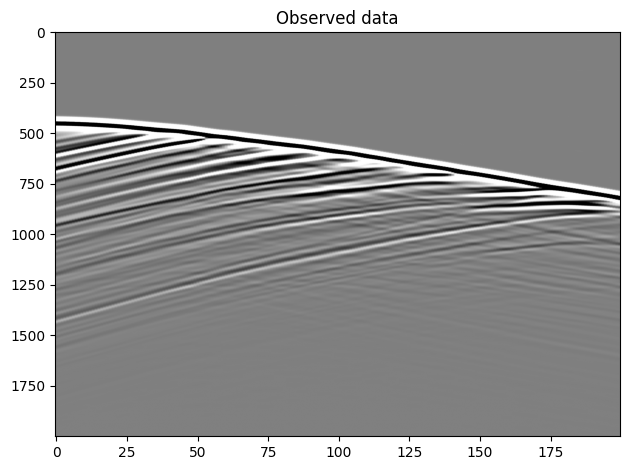

In [8]:
# Run forward modeling and display the observed data
# Training later tries to make the predicted model reproduce these records

d_obs, source_locations, receiver_locations, source_amplitudes = simulate_observed_data(
    vp_true=vp_true,
    config=survey_cfg,
    device=device,
)
plt.imshow(d_obs.squeeze().cpu().numpy()[0], cmap='gray', aspect='auto', vmax=0.1, vmin=-0.1)
plt.title('Observed data')
plt.tight_layout()
plt.show()


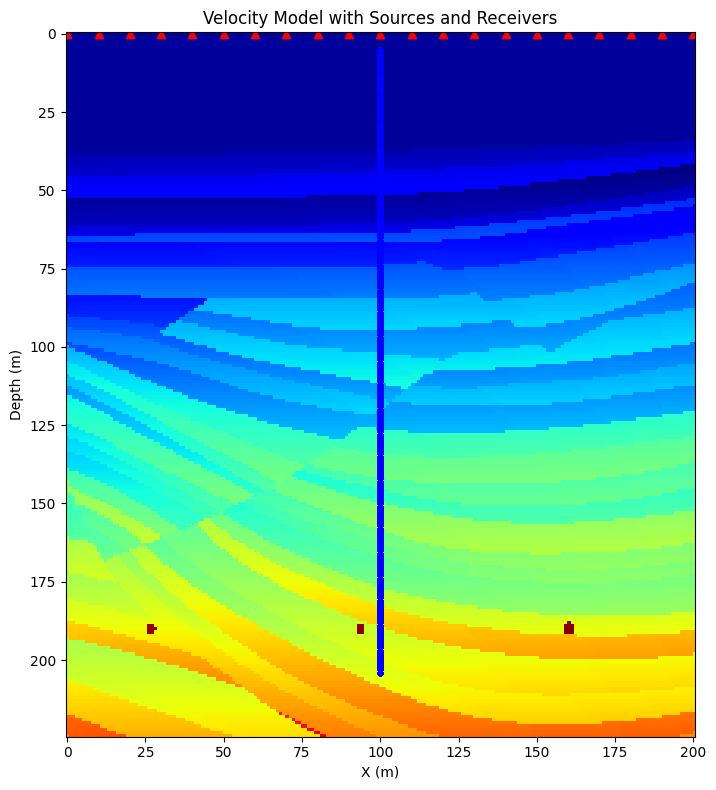

In [9]:
#Display the velocity model and acquisition geometry
# Red triangles are sources and blue dots are receivers

if isinstance(vp_true, torch.Tensor):
    vel_np = vp_true.detach().cpu().numpy().T
else:
    vel_np = vp_true.T

plt.figure(figsize=(10, 8))
plt.imshow(vel_np, cmap='jet')
source_x = source_locations[:, 0, 0].detach().cpu().numpy()
source_z = source_locations[:, 0, 1].detach().cpu().numpy()
plt.scatter(source_x, source_z, c='red', marker='^', label='Sources')
receiver_x = receiver_locations[:, :, 0].detach().cpu().numpy()
receiver_z = receiver_locations[:, :, 1].detach().cpu().numpy()
plt.scatter(receiver_x.flatten(), receiver_z.flatten(), c='blue', marker='o', s=10, label='Receivers')
plt.xlabel('X (m)')
plt.ylabel('Depth (m)')
plt.title('Velocity Model with Sources and Receivers')
plt.tight_layout()
plt.show()


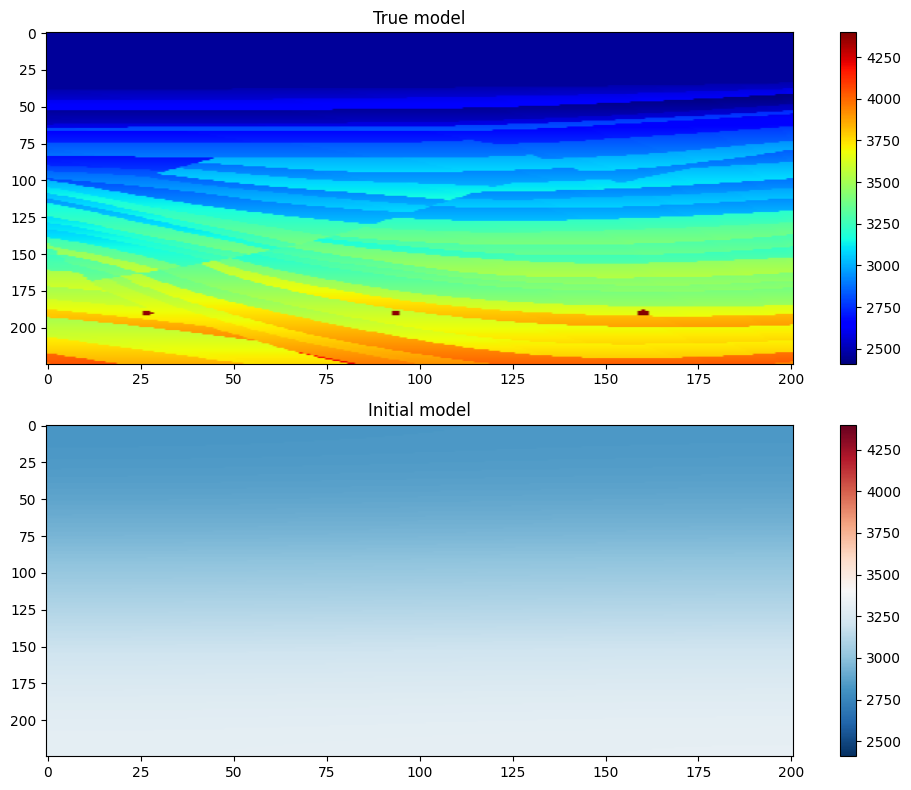

In [10]:
#  Display the true model and the initial model
# This gives a visual comparison before training starts

get_dir(Path)
vmin = np.min(vp_true.cpu().numpy())
vmax = np.max(vp_true.cpu().numpy())
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(vp_true.cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('True model')
plt.subplot(2, 1, 2)
plt.imshow(vp_initial.detach().cpu().numpy().T, cmap='RdBu_r', aspect='auto', vmax=vmax, vmin=vmin)
plt.colorbar()
plt.title('Initial model')
plt.tight_layout()
plt.show()


Iteration 1 ===== loss: 0.06209703446144149 for data and 257.216796875 for model
Iteration 2 ===== loss: 0.06124004561986242 for data and 256.9058837890625 for model
Iteration 3 ===== loss: 0.05990740834247498 for data and 257.48822021484375 for model
Iteration 4 ===== loss: 0.059262630130563466 for data and 258.40771484375 for model
Iteration 5 ===== loss: 0.05846624963340305 for data and 257.7061767578125 for model
Iteration 6 ===== loss: 0.05799605076511701 for data and 257.7723693847656 for model
Iteration 7 ===== loss: 0.05769371489683787 for data and 258.80084228515625 for model
Iteration 8 ===== loss: 0.055804801129159476 for data and 258.5530090332031 for model
Iteration 9 ===== loss: 0.057478727506739755 for data and 262.90887451171875 for model
Iteration 10 ===== loss: 0.056528822829325996 for data and 254.92953491210938 for model
Iteration 11 ===== loss: 0.05515692471748307 for data and 251.1616668701172 for model
Iteration 12 ===== loss: 0.05367014326509975 for data and 252

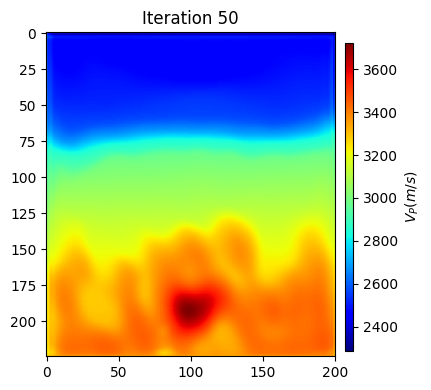

Iteration 51 ===== loss: 0.01081390403920696 for data and 121.72469329833984 for model
Iteration 52 ===== loss: 0.01090048479714564 for data and 120.85734558105469 for model
Iteration 53 ===== loss: 0.010741634427436761 for data and 120.32302856445312 for model
Iteration 54 ===== loss: 0.010778416879475117 for data and 119.81558990478516 for model
Iteration 55 ===== loss: 0.01074251834125746 for data and 121.93214416503906 for model
Iteration 56 ===== loss: 0.010653021479291576 for data and 120.6513900756836 for model
Iteration 57 ===== loss: 0.010623796399505366 for data and 119.77640533447266 for model
Iteration 58 ===== loss: 0.010425192303955555 for data and 120.0065689086914 for model
Iteration 59 ===== loss: 0.010469594925996802 for data and 119.32905578613281 for model
Iteration 60 ===== loss: 0.010248352862184956 for data and 118.872802734375 for model
Iteration 61 ===== loss: 0.01021050586409512 for data and 119.28604125976562 for model
Iteration 62 ===== loss: 0.0100571501645

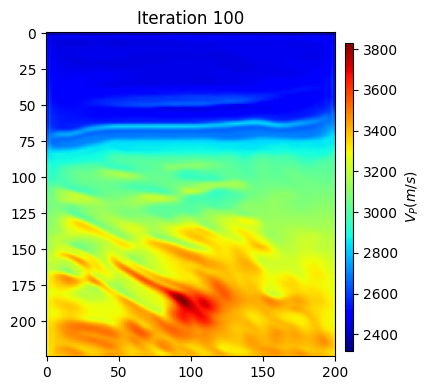

Iteration 101 ===== loss: 0.007576693137664171 for data and 116.94381713867188 for model
Iteration 102 ===== loss: 0.007394084152543829 for data and 117.21993255615234 for model
Iteration 103 ===== loss: 0.007370920053550175 for data and 118.71796417236328 for model
Iteration 104 ===== loss: 0.007295294066092798 for data and 117.63453674316406 for model
Iteration 105 ===== loss: 0.007248854020699149 for data and 118.07438659667969 for model
Iteration 106 ===== loss: 0.007183597267915805 for data and 117.90689849853516 for model
Iteration 107 ===== loss: 0.0071597046750996795 for data and 117.57195281982422 for model
Iteration 108 ===== loss: 0.007119492627680302 for data and 116.86569213867188 for model
Iteration 109 ===== loss: 0.006980189454874822 for data and 118.2591323852539 for model
Iteration 110 ===== loss: 0.006930701190694457 for data and 118.54874420166016 for model
Iteration 111 ===== loss: 0.0069948578962967505 for data and 117.53511810302734 for model
Iteration 112 ===== 

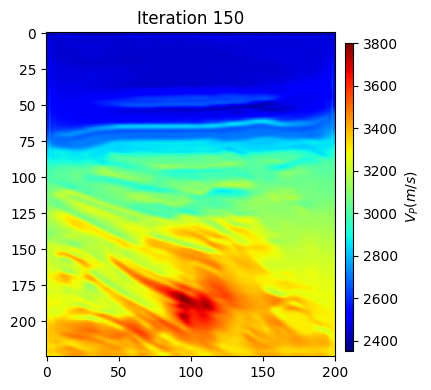

Iteration 151 ===== loss: 0.0057329457208869 for data and 116.40990447998047 for model
Iteration 152 ===== loss: 0.005675757592100473 for data and 115.7367172241211 for model
Iteration 153 ===== loss: 0.005597287123756749 for data and 115.82843780517578 for model
Iteration 154 ===== loss: 0.005669794976711273 for data and 116.98463439941406 for model
Iteration 155 ===== loss: 0.005564832328153508 for data and 115.67142486572266 for model
Iteration 156 ===== loss: 0.005697750996443487 for data and 115.92227935791016 for model
Iteration 157 ===== loss: 0.005461795277716149 for data and 115.71993255615234 for model
Iteration 158 ===== loss: 0.005600897994424615 for data and 115.98509979248047 for model
Iteration 159 ===== loss: 0.005487390904731694 for data and 115.8106460571289 for model
Iteration 160 ===== loss: 0.005547708166497094 for data and 115.8818588256836 for model
Iteration 161 ===== loss: 0.005532682695913883 for data and 116.14109802246094 for model
Iteration 162 ===== loss: 

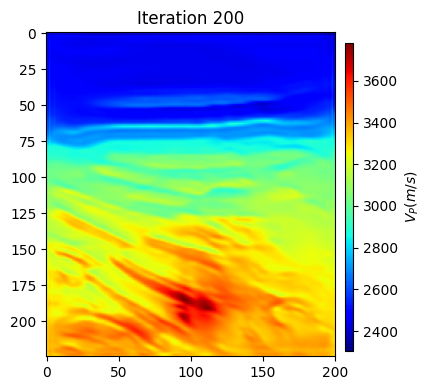

Iteration 201 ===== loss: 0.005012016056016797 for data and 112.76094055175781 for model
Iteration 202 ===== loss: 0.005014853485460792 for data and 113.5620346069336 for model
Iteration 203 ===== loss: 0.0050198955993567195 for data and 113.18693542480469 for model
Iteration 204 ===== loss: 0.004956592694811877 for data and 113.31391906738281 for model
Iteration 205 ===== loss: 0.005002656441536688 for data and 113.17101287841797 for model
Iteration 206 ===== loss: 0.004930147413341772 for data and 113.45689392089844 for model
Iteration 207 ===== loss: 0.004958459619610082 for data and 112.91981506347656 for model
Iteration 208 ===== loss: 0.004907738661304826 for data and 113.41622161865234 for model
Iteration 209 ===== loss: 0.004942338913679123 for data and 113.03872680664062 for model
Iteration 210 ===== loss: 0.004897639909315677 for data and 112.93960571289062 for model
Iteration 211 ===== loss: 0.004881331497537238 for data and 113.79661560058594 for model
Iteration 212 ===== l

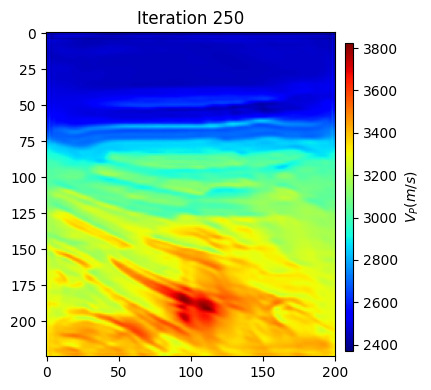

Iteration 251 ===== loss: 0.00460965179705194 for data and 110.70118713378906 for model
Iteration 252 ===== loss: 0.004571140921186833 for data and 111.11383056640625 for model
Iteration 253 ===== loss: 0.004550167736375616 for data and 110.90677642822266 for model
Iteration 254 ===== loss: 0.004537854188432296 for data and 110.47109985351562 for model
Iteration 255 ===== loss: 0.004642496850075466 for data and 110.94671630859375 for model
Iteration 256 ===== loss: 0.004500368709809014 for data and 110.34178161621094 for model
Iteration 257 ===== loss: 0.004498257545665616 for data and 110.48603820800781 for model
Iteration 258 ===== loss: 0.004511182595576558 for data and 110.93054962158203 for model
Iteration 259 ===== loss: 0.0044526720996059125 for data and 110.4668197631836 for model
Iteration 260 ===== loss: 0.004448699299246073 for data and 109.95658874511719 for model
Iteration 261 ===== loss: 0.0044841767687882695 for data and 109.82733154296875 for model
Iteration 262 ===== l

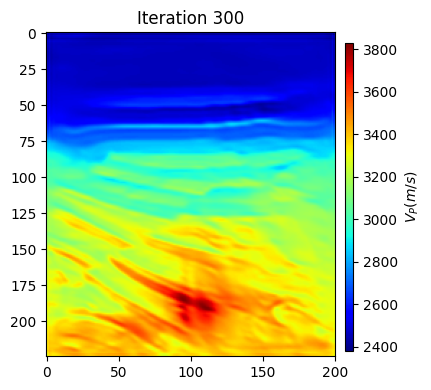

Iteration 301 ===== loss: 0.004267697954284293 for data and 107.91931915283203 for model
Iteration 302 ===== loss: 0.004260279338008591 for data and 108.24307250976562 for model
Iteration 303 ===== loss: 0.004257765820338612 for data and 108.29623413085938 for model
Iteration 304 ===== loss: 0.004188192986129295 for data and 108.00949096679688 for model
Iteration 305 ===== loss: 0.0042736525647342205 for data and 108.78392791748047 for model
Iteration 306 ===== loss: 0.0042398348894147645 for data and 108.91285705566406 for model
Iteration 307 ===== loss: 0.00420136328431822 for data and 107.86619567871094 for model
Iteration 308 ===== loss: 0.004218712005586852 for data and 108.69392395019531 for model
Iteration 309 ===== loss: 0.004186568183026144 for data and 107.95723724365234 for model
Iteration 310 ===== loss: 0.004260772007650563 for data and 108.78540802001953 for model
Iteration 311 ===== loss: 0.004108191833698324 for data and 107.8787841796875 for model
Iteration 312 ===== l

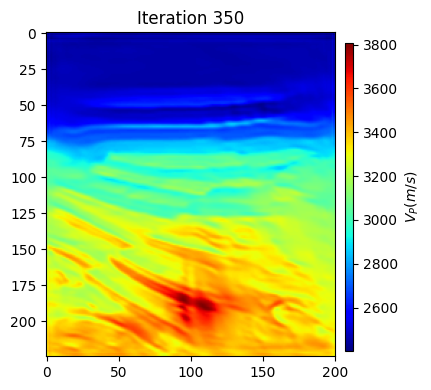

Iteration 351 ===== loss: 0.003988091534535799 for data and 107.1916732788086 for model
Iteration 352 ===== loss: 0.003968556544610432 for data and 107.0042724609375 for model
Iteration 353 ===== loss: 0.004037690592841024 for data and 106.78666687011719 for model
Iteration 354 ===== loss: 0.003965325997255388 for data and 106.7303695678711 for model
Iteration 355 ===== loss: 0.004012665522861339 for data and 106.74696350097656 for model
Iteration 356 ===== loss: 0.004070720324913661 for data and 106.61572265625 for model
Iteration 357 ===== loss: 0.003995038258532683 for data and 106.60401153564453 for model
Iteration 358 ===== loss: 0.004004341106684435 for data and 106.94074249267578 for model
Iteration 359 ===== loss: 0.003969202461164622 for data and 106.61344909667969 for model
Iteration 360 ===== loss: 0.004010113266607125 for data and 106.92205047607422 for model
Iteration 361 ===== loss: 0.0039696879463181605 for data and 107.00193786621094 for model
Iteration 362 ===== loss: 

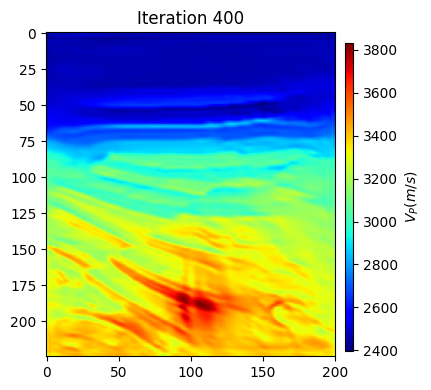

Iteration 401 ===== loss: 0.0038451598291950567 for data and 106.00296783447266 for model
Iteration 402 ===== loss: 0.003829911029675887 for data and 105.95541381835938 for model
Iteration 403 ===== loss: 0.003802647658934196 for data and 106.14903259277344 for model
Iteration 404 ===== loss: 0.003794994205236435 for data and 106.195556640625 for model
Iteration 405 ===== loss: 0.0037857945343213423 for data and 105.72106170654297 for model
Iteration 406 ===== loss: 0.0038278504230436824 for data and 105.92021942138672 for model
Iteration 407 ===== loss: 0.0037747895722055717 for data and 106.113525390625 for model
Iteration 408 ===== loss: 0.003803205354848788 for data and 105.90000915527344 for model
Iteration 409 ===== loss: 0.0038245536630884523 for data and 105.71795654296875 for model
Iteration 410 ===== loss: 0.003816027781881747 for data and 106.11450958251953 for model
Iteration 411 ===== loss: 0.0038225312961176748 for data and 105.78575897216797 for model
Iteration 412 =====

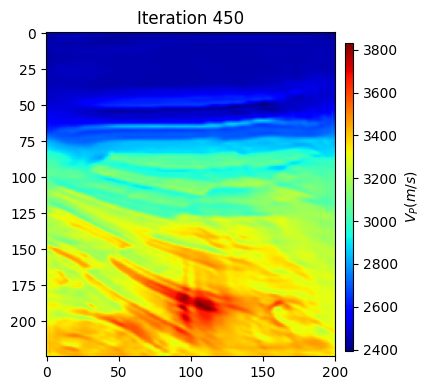

Iteration 451 ===== loss: 0.003662075348464506 for data and 104.6861343383789 for model
Iteration 452 ===== loss: 0.0037050594553528797 for data and 104.63847351074219 for model
Iteration 453 ===== loss: 0.0036579524277753775 for data and 104.65581512451172 for model
Iteration 454 ===== loss: 0.0036452812519634052 for data and 105.04181671142578 for model
Iteration 455 ===== loss: 0.003664176489803053 for data and 104.42328643798828 for model
Iteration 456 ===== loss: 0.0036101771651634146 for data and 104.58425903320312 for model
Iteration 457 ===== loss: 0.0037129891459785755 for data and 104.90733337402344 for model
Iteration 458 ===== loss: 0.003657936074194454 for data and 104.44825744628906 for model
Iteration 459 ===== loss: 0.003587911282444284 for data and 104.27305603027344 for model
Iteration 460 ===== loss: 0.0036588916665918772 for data and 104.46666717529297 for model
Iteration 461 ===== loss: 0.0036468912647770984 for data and 104.53792572021484 for model
Iteration 462 =

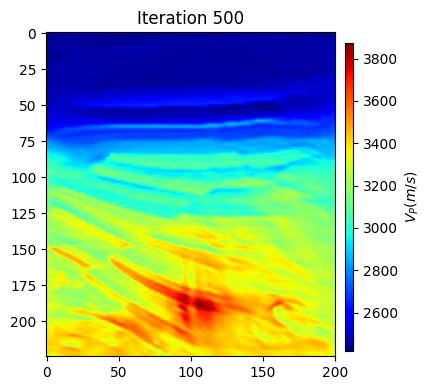

Iteration 501 ===== loss: 0.003538747074171191 for data and 103.1402816772461 for model
Iteration 502 ===== loss: 0.0035905782355084306 for data and 103.79639434814453 for model
Iteration 503 ===== loss: 0.0034773007833531927 for data and 103.4465560913086 for model
Iteration 504 ===== loss: 0.0035420631590698448 for data and 103.6834945678711 for model
Iteration 505 ===== loss: 0.0034859830491422187 for data and 103.20548248291016 for model
Iteration 506 ===== loss: 0.0035350827189783254 for data and 103.95529174804688 for model
Iteration 507 ===== loss: 0.003573782808546509 for data and 103.83097839355469 for model
Iteration 508 ===== loss: 0.003514686288932959 for data and 103.82757568359375 for model
Iteration 509 ===== loss: 0.0034881888423115015 for data and 103.84534454345703 for model
Iteration 510 ===== loss: 0.003544063606698598 for data and 103.10043334960938 for model
Iteration 511 ===== loss: 0.003524248942821508 for data and 103.1709213256836 for model
Iteration 512 =====

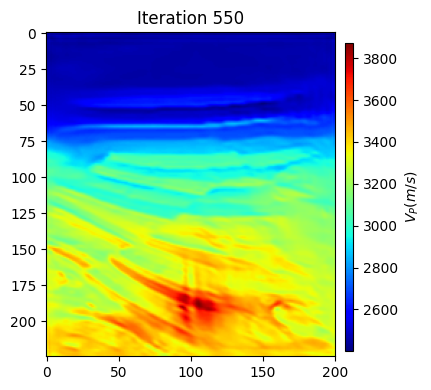

Iteration 551 ===== loss: 0.00344597189021962 for data and 102.04325103759766 for model
Iteration 552 ===== loss: 0.0034627518173129786 for data and 102.44232177734375 for model
Iteration 553 ===== loss: 0.003398387238294596 for data and 102.1283187866211 for model
Iteration 554 ===== loss: 0.0034926019475928377 for data and 102.4672622680664 for model
Iteration 555 ===== loss: 0.00338353059210238 for data and 102.39295196533203 for model
Iteration 556 ===== loss: 0.0034398033971055632 for data and 102.25614166259766 for model
Iteration 557 ===== loss: 0.003429975138888473 for data and 102.31266021728516 for model
Iteration 558 ===== loss: 0.0034212108834513594 for data and 102.1395034790039 for model
Iteration 559 ===== loss: 0.003373262006789446 for data and 102.17017364501953 for model
Iteration 560 ===== loss: 0.0034628584426605984 for data and 102.28976440429688 for model
Iteration 561 ===== loss: 0.003420114539386261 for data and 102.52433776855469 for model
Iteration 562 ===== l

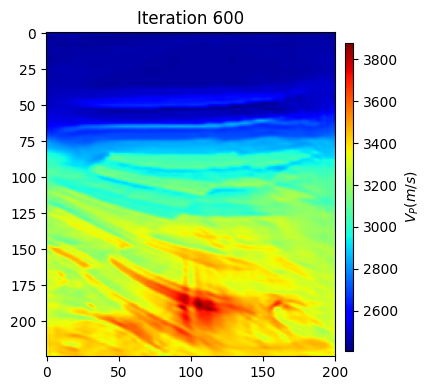

Iteration 601 ===== loss: 0.0033357806415075346 for data and 101.19135284423828 for model
Iteration 602 ===== loss: 0.003340895830964049 for data and 101.23174285888672 for model
Iteration 603 ===== loss: 0.0033231754565522784 for data and 101.24724578857422 for model
Iteration 604 ===== loss: 0.003376098759915857 for data and 101.0946273803711 for model
Iteration 605 ===== loss: 0.003325787683327993 for data and 101.18485260009766 for model
Iteration 606 ===== loss: 0.003321568603583035 for data and 101.11524963378906 for model
Iteration 607 ===== loss: 0.0033867943566292524 for data and 101.02859497070312 for model
Iteration 608 ===== loss: 0.0033252768085471223 for data and 100.938232421875 for model
Iteration 609 ===== loss: 0.003303373753581019 for data and 100.93737030029297 for model
Iteration 610 ===== loss: 0.003342029716198643 for data and 101.01890563964844 for model
Iteration 611 ===== loss: 0.0033236882605013392 for data and 101.0468978881836 for model
Iteration 612 ===== 

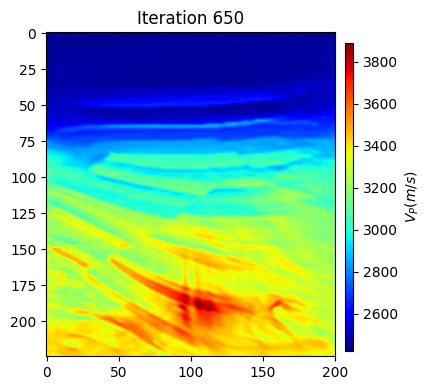

Iteration 651 ===== loss: 0.0032881757111421655 for data and 100.56634521484375 for model
Iteration 652 ===== loss: 0.003246336277308209 for data and 100.587158203125 for model
Iteration 653 ===== loss: 0.0032529456962254785 for data and 100.44313049316406 for model
Iteration 654 ===== loss: 0.003273981734223309 for data and 100.3580322265625 for model
Iteration 655 ===== loss: 0.0032864163319269815 for data and 100.64604187011719 for model
Iteration 656 ===== loss: 0.0032174575829967147 for data and 100.41038513183594 for model
Iteration 657 ===== loss: 0.0032550635348473278 for data and 100.52405548095703 for model
Iteration 658 ===== loss: 0.0032130159060692505 for data and 100.58057403564453 for model
Iteration 659 ===== loss: 0.0032438041220995643 for data and 100.39364624023438 for model
Iteration 660 ===== loss: 0.0032393431645773704 for data and 100.26691436767578 for model
Iteration 661 ===== loss: 0.00327471142546052 for data and 100.75495910644531 for model
Iteration 662 ===

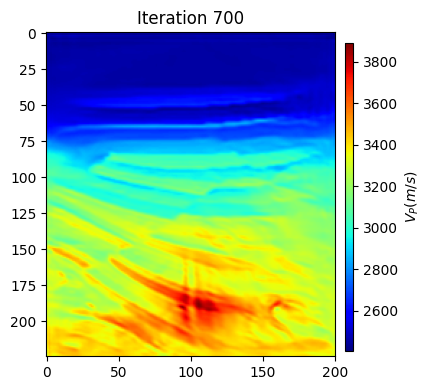

Iteration 701 ===== loss: 0.0031664790807380563 for data and 100.01077270507812 for model
Iteration 702 ===== loss: 0.003141326153473485 for data and 99.87107849121094 for model
Iteration 703 ===== loss: 0.0031663438504827873 for data and 99.94438171386719 for model
Iteration 704 ===== loss: 0.0031811116440665153 for data and 99.76266479492188 for model
Iteration 705 ===== loss: 0.0031865717111421482 for data and 100.26950073242188 for model
Iteration 706 ===== loss: 0.0031348439376978647 for data and 99.81578063964844 for model
Iteration 707 ===== loss: 0.003212342349191507 for data and 99.95093536376953 for model
Iteration 708 ===== loss: 0.003120828674928773 for data and 99.66867065429688 for model
Iteration 709 ===== loss: 0.0032335059340333656 for data and 99.42565155029297 for model
Iteration 710 ===== loss: 0.0031834660718838372 for data and 99.53050231933594 for model
Iteration 711 ===== loss: 0.00318102931071605 for data and 100.03089904785156 for model
Iteration 712 ===== los

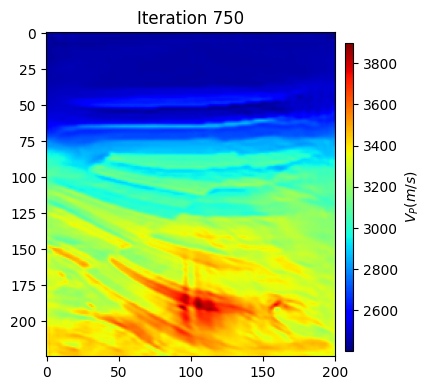

Iteration 751 ===== loss: 0.0031479834024572655 for data and 99.10601806640625 for model
Iteration 752 ===== loss: 0.00311402682702811 for data and 99.0804214477539 for model
Iteration 753 ===== loss: 0.0031419385645893357 for data and 99.07001495361328 for model
Iteration 754 ===== loss: 0.003102219430729747 for data and 99.2352066040039 for model
Iteration 755 ===== loss: 0.0031255392269009634 for data and 98.98281860351562 for model
Iteration 756 ===== loss: 0.0031293234787881374 for data and 99.09061431884766 for model
Iteration 757 ===== loss: 0.003123017992558224 for data and 98.94330596923828 for model
Iteration 758 ===== loss: 0.0030726466682695205 for data and 98.90777587890625 for model
Iteration 759 ===== loss: 0.0031367072480775063 for data and 99.0190200805664 for model
Iteration 760 ===== loss: 0.0031074874346987123 for data and 98.90715789794922 for model
Iteration 761 ===== loss: 0.0030767745892739014 for data and 99.35808563232422 for model
Iteration 762 ===== loss: 0.

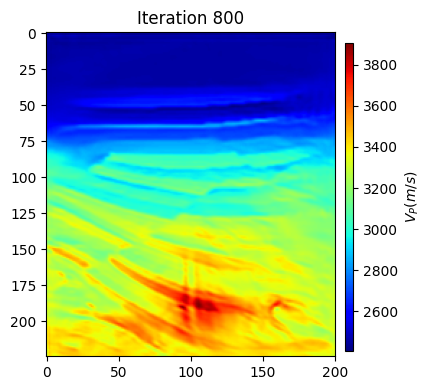

Iteration 801 ===== loss: 0.0030494466911823977 for data and 98.49201202392578 for model
Iteration 802 ===== loss: 0.003041464125826245 for data and 98.64765167236328 for model
Iteration 803 ===== loss: 0.0030590587938647894 for data and 99.04632568359375 for model
Iteration 804 ===== loss: 0.003049763496078196 for data and 98.69673919677734 for model
Iteration 805 ===== loss: 0.0030484232120215893 for data and 98.71945190429688 for model
Iteration 806 ===== loss: 0.0030699020606421287 for data and 98.65428924560547 for model
Iteration 807 ===== loss: 0.0030809962855918066 for data and 98.39017486572266 for model
Iteration 808 ===== loss: 0.003025374330935024 for data and 98.96634674072266 for model
Iteration 809 ===== loss: 0.0030639912888762496 for data and 99.10843658447266 for model
Iteration 810 ===== loss: 0.003076638937706039 for data and 98.6187973022461 for model
Iteration 811 ===== loss: 0.0030670012458271926 for data and 98.71295928955078 for model
Iteration 812 ===== loss: 

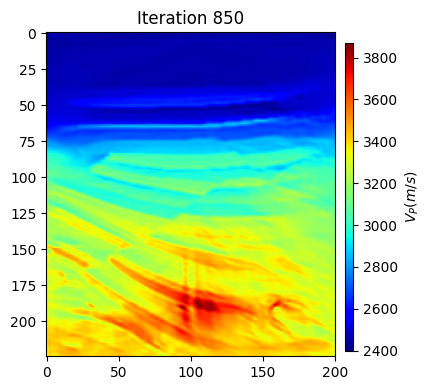

Iteration 851 ===== loss: 0.0029854787779705866 for data and 98.6631088256836 for model
Iteration 852 ===== loss: 0.0030243678484112024 for data and 98.56926727294922 for model
Iteration 853 ===== loss: 0.003033687282974521 for data and 98.60865020751953 for model
Iteration 854 ===== loss: 0.0029808777672726485 for data and 98.24121856689453 for model
Iteration 855 ===== loss: 0.003033653400572283 for data and 98.36913299560547 for model
Iteration 856 ===== loss: 0.0030221083933221443 for data and 98.37480926513672 for model
Iteration 857 ===== loss: 0.002993339251372076 for data and 98.64051055908203 for model
Iteration 858 ===== loss: 0.002983339884806247 for data and 98.32422637939453 for model
Iteration 859 ===== loss: 0.003042260595109491 for data and 98.52022552490234 for model
Iteration 860 ===== loss: 0.0030246144936730466 for data and 98.40972137451172 for model
Iteration 861 ===== loss: 0.0029617084101552053 for data and 98.80387115478516 for model
Iteration 862 ===== loss: 0

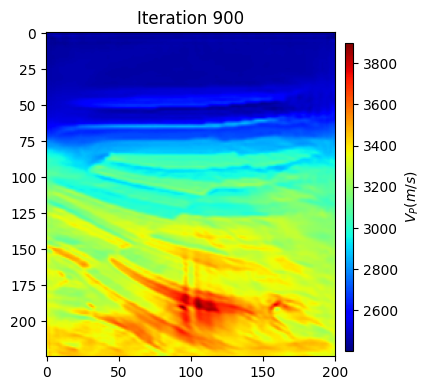

Iteration 901 ===== loss: 0.002996903999398152 for data and 97.53417205810547 for model
Iteration 902 ===== loss: 0.002954613949571337 for data and 97.94788360595703 for model
Iteration 903 ===== loss: 0.0029242979362607002 for data and 97.88662719726562 for model
Iteration 904 ===== loss: 0.002974391593376086 for data and 98.1666030883789 for model
Iteration 905 ===== loss: 0.002900098284174289 for data and 98.24717712402344 for model
Iteration 906 ===== loss: 0.002936183541480984 for data and 97.72358703613281 for model
Iteration 907 ===== loss: 0.002962795052943485 for data and 97.97449493408203 for model
Iteration 908 ===== loss: 0.0029581739744614986 for data and 97.8002700805664 for model
Iteration 909 ===== loss: 0.002976536861665192 for data and 97.69921875 for model
Iteration 910 ===== loss: 0.0029456796390669687 for data and 97.96451568603516 for model
Iteration 911 ===== loss: 0.0030002758749538942 for data and 97.89163208007812 for model
Iteration 912 ===== loss: 0.00292578

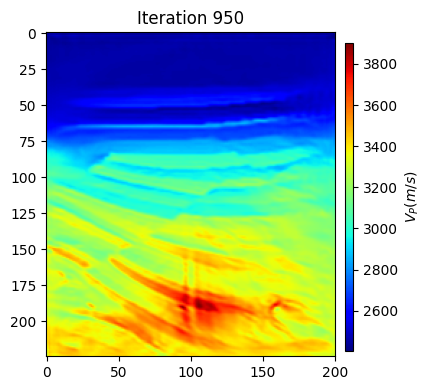

Iteration 951 ===== loss: 0.0029110940993719156 for data and 97.5243911743164 for model
Iteration 952 ===== loss: 0.002902955249218004 for data and 97.96935272216797 for model
Iteration 953 ===== loss: 0.0028902458780932995 for data and 97.96371459960938 for model
Iteration 954 ===== loss: 0.0029350175034432184 for data and 97.716552734375 for model
Iteration 955 ===== loss: 0.00293022445181296 for data and 97.56969451904297 for model
Iteration 956 ===== loss: 0.0029024272004053706 for data and 97.80936431884766 for model
Iteration 957 ===== loss: 0.0028976936203738055 for data and 97.9980697631836 for model
Iteration 958 ===== loss: 0.002932771652316054 for data and 97.48568725585938 for model
Iteration 959 ===== loss: 0.0028903219361035596 for data and 97.6080093383789 for model
Iteration 960 ===== loss: 0.0029134306214040236 for data and 97.62761688232422 for model
Iteration 961 ===== loss: 0.002945944977303346 for data and 97.8461685180664 for model
Iteration 962 ===== loss: 0.0029

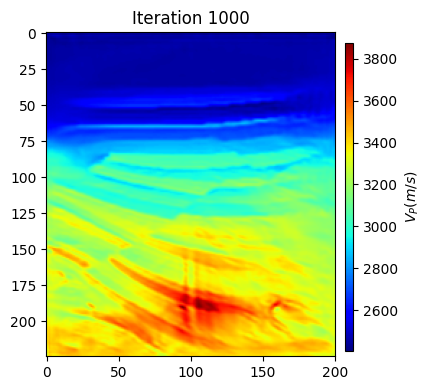

Iteration 1001 ===== loss: 0.002838625262180964 for data and 97.35425567626953 for model
Iteration 1002 ===== loss: 0.0028890258787820735 for data and 97.46516418457031 for model
Iteration 1003 ===== loss: 0.0028892942438168184 for data and 97.02806091308594 for model
Iteration 1004 ===== loss: 0.0028949383690598466 for data and 97.29557037353516 for model
Iteration 1005 ===== loss: 0.002853576714793841 for data and 97.39427185058594 for model
Iteration 1006 ===== loss: 0.002828112692527828 for data and 97.38114929199219 for model
Iteration 1007 ===== loss: 0.002851813987252258 for data and 97.25800323486328 for model
Iteration 1008 ===== loss: 0.0028953755141368936 for data and 97.30498504638672 for model
Iteration 1009 ===== loss: 0.0028603953043265 for data and 97.26371765136719 for model
Iteration 1010 ===== loss: 0.002834169205189461 for data and 97.49103546142578 for model
Iteration 1011 ===== loss: 0.002948286155948327 for data and 97.58182525634766 for model
Iteration 1012 ====

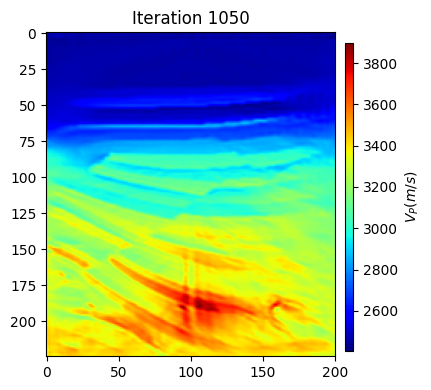

Iteration 1051 ===== loss: 0.0028388583700039555 for data and 97.36605834960938 for model
Iteration 1052 ===== loss: 0.0029046477838641123 for data and 97.36248016357422 for model
Iteration 1053 ===== loss: 0.0028580136131495237 for data and 97.46336364746094 for model
Iteration 1054 ===== loss: 0.0028407650755807048 for data and 97.4389419555664 for model
Iteration 1055 ===== loss: 0.0028978669683315922 for data and 97.06713104248047 for model
Iteration 1056 ===== loss: 0.0029176174374740747 for data and 97.20587158203125 for model
Iteration 1057 ===== loss: 0.002808868441553343 for data and 97.24173736572266 for model
Iteration 1058 ===== loss: 0.0028616771589787234 for data and 97.0112533569336 for model
Iteration 1059 ===== loss: 0.0029101276415444558 for data and 97.10919189453125 for model
Iteration 1060 ===== loss: 0.002862942793096105 for data and 97.01351165771484 for model
Iteration 1061 ===== loss: 0.002846010395192674 for data and 96.72893524169922 for model
Iteration 1062 

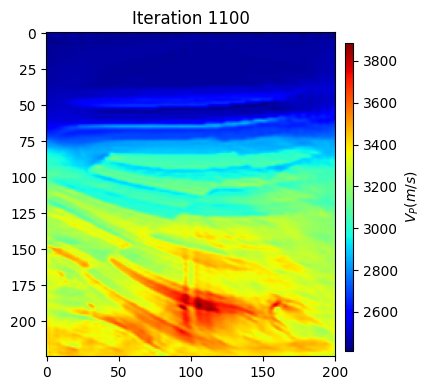

Iteration 1101 ===== loss: 0.002832737939787053 for data and 96.70542907714844 for model
Iteration 1102 ===== loss: 0.0027893130401415484 for data and 96.74392700195312 for model
Iteration 1103 ===== loss: 0.00278604059435782 for data and 96.66036987304688 for model
Iteration 1104 ===== loss: 0.0028631355990433975 for data and 96.87478637695312 for model
Iteration 1105 ===== loss: 0.0027734677285133373 for data and 96.84683227539062 for model
Iteration 1106 ===== loss: 0.0027513184828595037 for data and 96.9497299194336 for model
Iteration 1107 ===== loss: 0.002847400183478991 for data and 96.86840057373047 for model
Iteration 1108 ===== loss: 0.002817487410668816 for data and 96.90238189697266 for model
Iteration 1109 ===== loss: 0.0027681092642957254 for data and 96.79080200195312 for model
Iteration 1110 ===== loss: 0.002770769864409452 for data and 97.12972259521484 for model
Iteration 1111 ===== loss: 0.00287269759878871 for data and 96.95177459716797 for model
Iteration 1112 ====

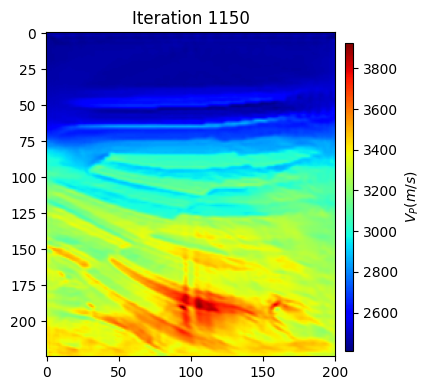

Iteration 1151 ===== loss: 0.00278156118777891 for data and 96.56454467773438 for model
Iteration 1152 ===== loss: 0.002780340678457703 for data and 96.3740005493164 for model
Iteration 1153 ===== loss: 0.0027948504069908744 for data and 96.486083984375 for model
Iteration 1154 ===== loss: 0.002781500285934834 for data and 96.38339233398438 for model
Iteration 1155 ===== loss: 0.0027965965481208904 for data and 96.24180603027344 for model
Iteration 1156 ===== loss: 0.00275051620389734 for data and 96.44404602050781 for model
Iteration 1157 ===== loss: 0.002788716461509466 for data and 96.2131576538086 for model
Iteration 1158 ===== loss: 0.0027262018882625158 for data and 96.46876525878906 for model
Iteration 1159 ===== loss: 0.0027719592520346246 for data and 96.11048126220703 for model
Iteration 1160 ===== loss: 0.00275386945300159 for data and 96.56077575683594 for model
Iteration 1161 ===== loss: 0.002797317314183428 for data and 96.13690948486328 for model
Iteration 1162 ===== los

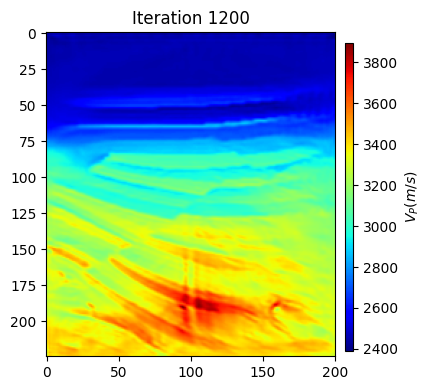

Iteration 1201 ===== loss: 0.00280502669158436 for data and 95.68157958984375 for model
Iteration 1202 ===== loss: 0.002780718518243659 for data and 95.88360595703125 for model
Iteration 1203 ===== loss: 0.0027435853234713987 for data and 95.77267456054688 for model
Iteration 1204 ===== loss: 0.002773142963026961 for data and 96.02188110351562 for model
Iteration 1205 ===== loss: 0.0026981725601390714 for data and 95.77154541015625 for model
Iteration 1206 ===== loss: 0.0027076787803144682 for data and 95.90133666992188 for model
Iteration 1207 ===== loss: 0.002737355473939152 for data and 96.19422912597656 for model
Iteration 1208 ===== loss: 0.0027578400248395546 for data and 96.03642272949219 for model
Iteration 1209 ===== loss: 0.002731510293891742 for data and 95.79414367675781 for model
Iteration 1210 ===== loss: 0.002729688183448854 for data and 96.1092300415039 for model
Iteration 1211 ===== loss: 0.002722442737736163 for data and 96.17910766601562 for model
Iteration 1212 ====

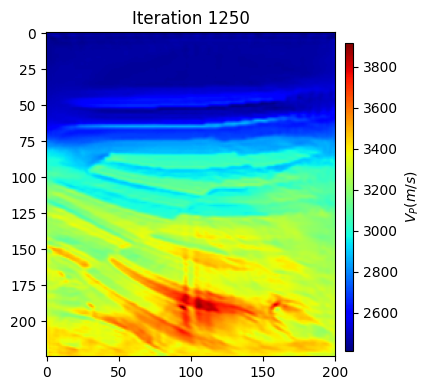

Iteration 1251 ===== loss: 0.002783780972961159 for data and 95.58039093017578 for model
Iteration 1252 ===== loss: 0.002624383284932091 for data and 95.54582977294922 for model
Iteration 1253 ===== loss: 0.0027367017852763333 for data and 95.56692504882812 for model
Iteration 1254 ===== loss: 0.0027697373270278887 for data and 95.76143646240234 for model
Iteration 1255 ===== loss: 0.0026497444404023035 for data and 95.50640106201172 for model
Iteration 1256 ===== loss: 0.00273053883574903 for data and 95.80520629882812 for model
Iteration 1257 ===== loss: 0.002724228548772988 for data and 95.68868255615234 for model
Iteration 1258 ===== loss: 0.0026800481136888266 for data and 95.88111877441406 for model
Iteration 1259 ===== loss: 0.0027489526019919487 for data and 95.49730682373047 for model
Iteration 1260 ===== loss: 0.002743706428667619 for data and 95.64545440673828 for model
Iteration 1261 ===== loss: 0.002717827313712665 for data and 95.48566436767578 for model
Iteration 1262 ==

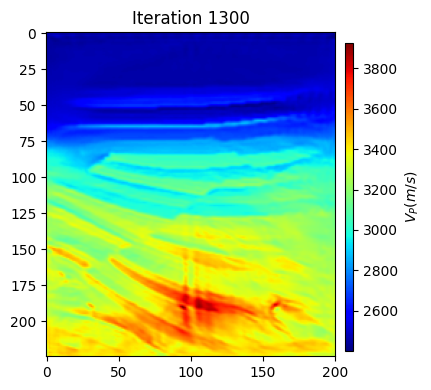

Iteration 1301 ===== loss: 0.0027447641561073916 for data and 95.41466522216797 for model
Iteration 1302 ===== loss: 0.0026750601162867887 for data and 95.38916778564453 for model
Iteration 1303 ===== loss: 0.0026784679475462154 for data and 95.12236785888672 for model
Iteration 1304 ===== loss: 0.002721517069620036 for data and 95.1313247680664 for model
Iteration 1305 ===== loss: 0.002639712810161568 for data and 95.1593246459961 for model
Iteration 1306 ===== loss: 0.0027056930121034384 for data and 94.79950714111328 for model
Iteration 1307 ===== loss: 0.00266689766154048 for data and 94.8851547241211 for model
Iteration 1308 ===== loss: 0.0026410080470322143 for data and 95.00457763671875 for model
Iteration 1309 ===== loss: 0.0027103296015411615 for data and 94.96984100341797 for model
Iteration 1310 ===== loss: 0.0026432569027833993 for data and 95.55122375488281 for model
Iteration 1311 ===== loss: 0.0026796876031550624 for data and 95.0752944946289 for model
Iteration 1312 ===

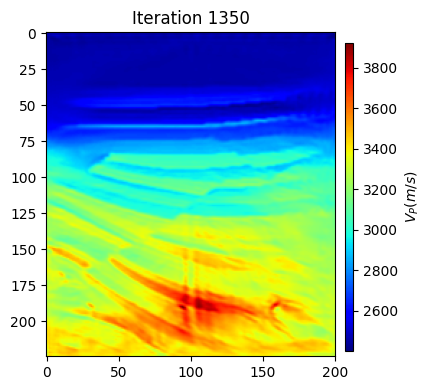

Iteration 1351 ===== loss: 0.002658079367219692 for data and 94.83427429199219 for model
Iteration 1352 ===== loss: 0.002618954849562475 for data and 94.725341796875 for model
Iteration 1353 ===== loss: 0.002744456808570595 for data and 94.47262573242188 for model
Iteration 1354 ===== loss: 0.0026086386448393264 for data and 94.81282806396484 for model
Iteration 1355 ===== loss: 0.0026207653739090475 for data and 94.6487808227539 for model
Iteration 1356 ===== loss: 0.002703812638563769 for data and 94.74415588378906 for model
Iteration 1357 ===== loss: 0.0026205264009712707 for data and 94.80968475341797 for model
Iteration 1358 ===== loss: 0.002648701968913277 for data and 95.05342102050781 for model
Iteration 1359 ===== loss: 0.0026306662974613054 for data and 94.9563980102539 for model
Iteration 1360 ===== loss: 0.002657184610143304 for data and 94.86088562011719 for model
Iteration 1361 ===== loss: 0.002657018280366347 for data and 95.00096130371094 for model
Iteration 1362 ===== 

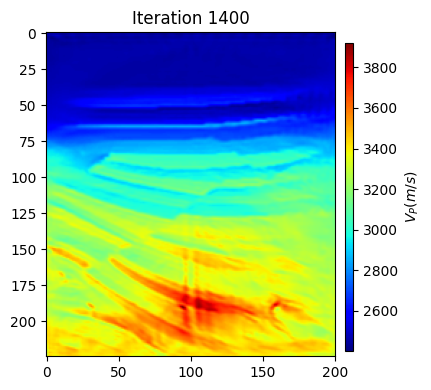

Iteration 1401 ===== loss: 0.0025824995134912784 for data and 94.55708312988281 for model
Iteration 1402 ===== loss: 0.002636905027819531 for data and 94.62040710449219 for model
Iteration 1403 ===== loss: 0.002661264922824644 for data and 94.475830078125 for model
Iteration 1404 ===== loss: 0.0026263617466957797 for data and 94.56748962402344 for model
Iteration 1405 ===== loss: 0.0026087366887146517 for data and 94.99739074707031 for model
Iteration 1406 ===== loss: 0.0026627585535780305 for data and 94.79800415039062 for model
Iteration 1407 ===== loss: 0.0026519664541064273 for data and 94.82140350341797 for model
Iteration 1408 ===== loss: 0.0026514862797089984 for data and 94.77637481689453 for model
Iteration 1409 ===== loss: 0.0026024769703369764 for data and 94.76087188720703 for model
Iteration 1410 ===== loss: 0.0026634727671210256 for data and 94.67514038085938 for model
Iteration 1411 ===== loss: 0.0025916957806441047 for data and 94.58025360107422 for model
Iteration 1412

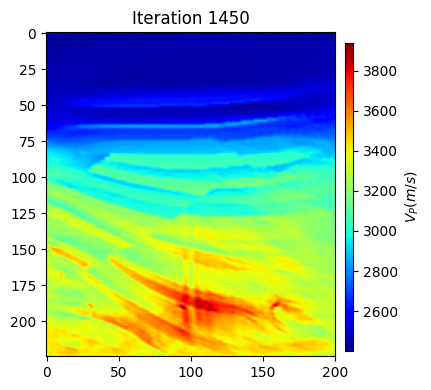

Iteration 1451 ===== loss: 0.002571738480279843 for data and 94.32257843017578 for model
Iteration 1452 ===== loss: 0.0025938971832926783 for data and 94.20094299316406 for model
Iteration 1453 ===== loss: 0.0025807119950297334 for data and 94.11714172363281 for model
Iteration 1454 ===== loss: 0.0025695047252589746 for data and 94.29136657714844 for model
Iteration 1455 ===== loss: 0.0025614325201050157 for data and 94.18645477294922 for model
Iteration 1456 ===== loss: 0.0026296983539525953 for data and 94.50872802734375 for model
Iteration 1457 ===== loss: 0.0025780607081417528 for data and 94.43641662597656 for model
Iteration 1458 ===== loss: 0.00261558878368565 for data and 94.12726593017578 for model
Iteration 1459 ===== loss: 0.0025863267060014464 for data and 94.06609344482422 for model
Iteration 1460 ===== loss: 0.002586765658287775 for data and 94.35029602050781 for model
Iteration 1461 ===== loss: 0.0025446722616574596 for data and 93.90089416503906 for model
Iteration 1462

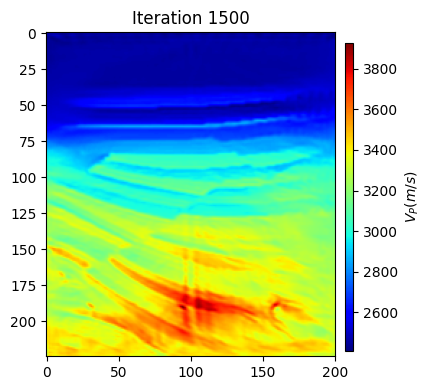

Iteration 1501 ===== loss: 0.002553970464283512 for data and 93.80613708496094 for model
Iteration 1502 ===== loss: 0.002554626702996237 for data and 94.00331115722656 for model
Iteration 1503 ===== loss: 0.0025864042053442625 for data and 94.22411346435547 for model
Iteration 1504 ===== loss: 0.0025470417125948836 for data and 94.4023208618164 for model
Iteration 1505 ===== loss: 0.002585914074665024 for data and 94.2138900756836 for model
Iteration 1506 ===== loss: 0.0025964753502713783 for data and 94.04158020019531 for model
Iteration 1507 ===== loss: 0.0025922702403650398 for data and 94.11026000976562 for model
Iteration 1508 ===== loss: 0.002542927173808927 for data and 94.17254638671875 for model
Iteration 1509 ===== loss: 0.002590715984946915 for data and 93.77179718017578 for model
Iteration 1510 ===== loss: 0.00255673649233012 for data and 93.75700378417969 for model
Iteration 1511 ===== loss: 0.0025929634880629323 for data and 93.98576354980469 for model
Iteration 1512 ====

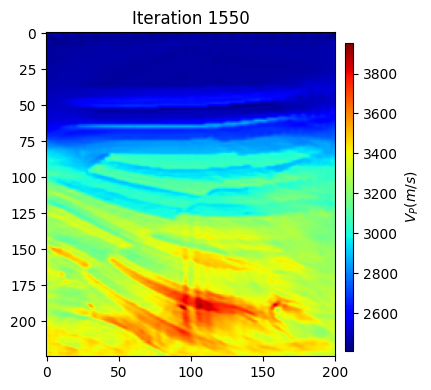

Iteration 1551 ===== loss: 0.002541577886967432 for data and 93.50730895996094 for model
Iteration 1552 ===== loss: 0.002517368688824631 for data and 93.5650634765625 for model
Iteration 1553 ===== loss: 0.0025839805492155607 for data and 93.71785736083984 for model
Iteration 1554 ===== loss: 0.0025838149622792288 for data and 93.7053451538086 for model
Iteration 1555 ===== loss: 0.0025734465702303816 for data and 93.61788940429688 for model
Iteration 1556 ===== loss: 0.00252715120136383 for data and 93.63593292236328 for model
Iteration 1557 ===== loss: 0.0025549072528346663 for data and 93.63175201416016 for model
Iteration 1558 ===== loss: 0.002583079428101579 for data and 93.4443588256836 for model
Iteration 1559 ===== loss: 0.0025535262012410733 for data and 93.45233917236328 for model
Iteration 1560 ===== loss: 0.0025281961563797225 for data and 93.45868682861328 for model
Iteration 1561 ===== loss: 0.0025453498320920126 for data and 93.2113265991211 for model
Iteration 1562 ====

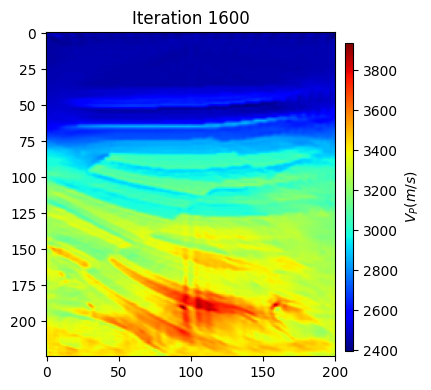

Iteration 1601 ===== loss: 0.00256600314086037 for data and 93.48468780517578 for model
Iteration 1602 ===== loss: 0.0025487984752371197 for data and 93.10779571533203 for model
Iteration 1603 ===== loss: 0.002514905795188887 for data and 93.2630615234375 for model
Iteration 1604 ===== loss: 0.0024855854654950754 for data and 93.21293640136719 for model
Iteration 1605 ===== loss: 0.0025564804007964475 for data and 93.06597137451172 for model
Iteration 1606 ===== loss: 0.0025098152303447327 for data and 92.98209381103516 for model
Iteration 1607 ===== loss: 0.0025373519220877262 for data and 93.16256713867188 for model
Iteration 1608 ===== loss: 0.0024945028569726716 for data and 93.17345428466797 for model
Iteration 1609 ===== loss: 0.0025403329636901617 for data and 93.12450408935547 for model
Iteration 1610 ===== loss: 0.002501741550596697 for data and 93.02536010742188 for model
Iteration 1611 ===== loss: 0.0025200570844823404 for data and 93.01671600341797 for model
Iteration 1612 

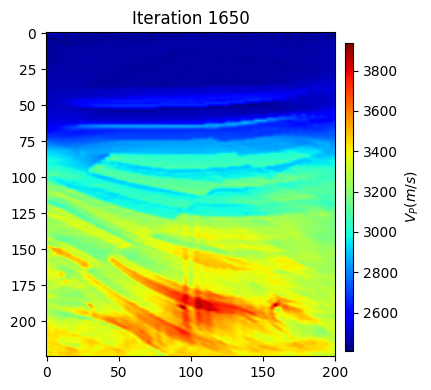

Iteration 1651 ===== loss: 0.0025091696574929215 for data and 92.78923034667969 for model
Iteration 1652 ===== loss: 0.0024726250475006445 for data and 92.80091094970703 for model
Iteration 1653 ===== loss: 0.0024799738367575976 for data and 92.9529037475586 for model
Iteration 1654 ===== loss: 0.002534658925253011 for data and 92.61995697021484 for model
Iteration 1655 ===== loss: 0.0025273330975323915 for data and 92.89189910888672 for model
Iteration 1656 ===== loss: 0.0024899498093873262 for data and 92.94125366210938 for model
Iteration 1657 ===== loss: 0.002508770474897964 for data and 92.93678283691406 for model
Iteration 1658 ===== loss: 0.0024821890207628408 for data and 92.9626235961914 for model
Iteration 1659 ===== loss: 0.002530127808096863 for data and 92.54557037353516 for model
Iteration 1660 ===== loss: 0.002475861515406342 for data and 92.95543670654297 for model
Iteration 1661 ===== loss: 0.002480501142729606 for data and 92.9883041381836 for model
Iteration 1662 ===

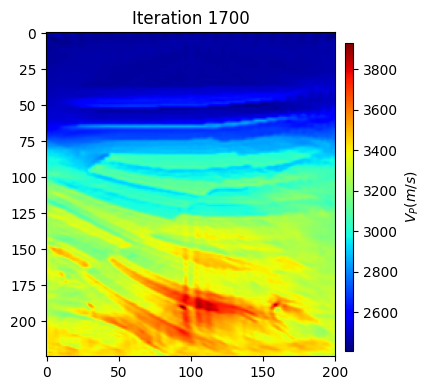

Iteration 1701 ===== loss: 0.002509267158096745 for data and 92.63275146484375 for model
Iteration 1702 ===== loss: 0.0024996052074822642 for data and 92.62020874023438 for model
Iteration 1703 ===== loss: 0.002493066569080665 for data and 92.6107406616211 for model
Iteration 1704 ===== loss: 0.002448151930279675 for data and 92.6321792602539 for model
Iteration 1705 ===== loss: 0.0024899414496585017 for data and 92.81022644042969 for model
Iteration 1706 ===== loss: 0.002473228012344667 for data and 92.63813018798828 for model
Iteration 1707 ===== loss: 0.0024924934952564185 for data and 92.5216064453125 for model
Iteration 1708 ===== loss: 0.002496498581465511 for data and 92.3471908569336 for model
Iteration 1709 ===== loss: 0.0024520690397669873 for data and 92.5648422241211 for model
Iteration 1710 ===== loss: 0.002502329869284516 for data and 92.54839324951172 for model
Iteration 1711 ===== loss: 0.0024849745067989544 for data and 92.85568237304688 for model
Iteration 1712 ===== 

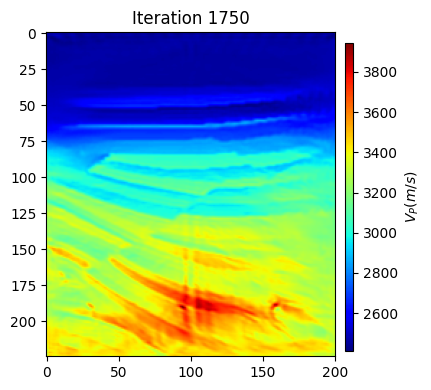

Iteration 1751 ===== loss: 0.0024562664773492586 for data and 92.36753845214844 for model
Iteration 1752 ===== loss: 0.0024544648892645326 for data and 92.31355285644531 for model
Iteration 1753 ===== loss: 0.0024236163922718595 for data and 92.37255859375 for model
Iteration 1754 ===== loss: 0.00249813829681703 for data and 92.01094818115234 for model
Iteration 1755 ===== loss: 0.002434693698194765 for data and 92.1636962890625 for model
Iteration 1756 ===== loss: 0.0024715410878083537 for data and 92.22196197509766 for model
Iteration 1757 ===== loss: 0.002467126574455982 for data and 92.23816680908203 for model
Iteration 1758 ===== loss: 0.0024587196031851427 for data and 92.32624053955078 for model
Iteration 1759 ===== loss: 0.0024533533890332493 for data and 92.24786376953125 for model
Iteration 1760 ===== loss: 0.0024528760973009326 for data and 92.32617950439453 for model
Iteration 1761 ===== loss: 0.0024508732326683543 for data and 92.27869415283203 for model
Iteration 1762 ===

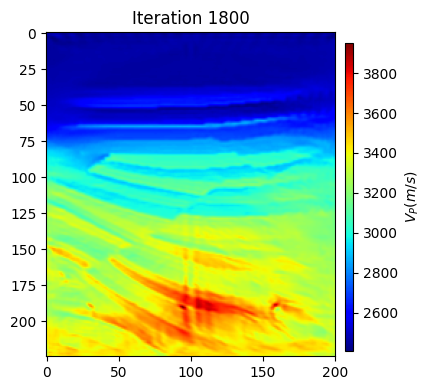

Iteration 1801 ===== loss: 0.0024115877736005046 for data and 91.93037414550781 for model
Iteration 1802 ===== loss: 0.002504094226640605 for data and 91.88668823242188 for model
Iteration 1803 ===== loss: 0.002479404621269731 for data and 92.12396240234375 for model
Iteration 1804 ===== loss: 0.0024217565854390464 for data and 92.05253601074219 for model
Iteration 1805 ===== loss: 0.002421251775342084 for data and 92.0687484741211 for model
Iteration 1806 ===== loss: 0.002507409169560387 for data and 92.04731750488281 for model
Iteration 1807 ===== loss: 0.0024407170712947845 for data and 91.89302825927734 for model
Iteration 1808 ===== loss: 0.0024660781491547823 for data and 91.78413391113281 for model
Iteration 1809 ===== loss: 0.0024154543477509704 for data and 92.07230377197266 for model
Iteration 1810 ===== loss: 0.002449957077347097 for data and 92.0447998046875 for model
Iteration 1811 ===== loss: 0.00244488246694562 for data and 91.91320037841797 for model
Iteration 1812 ====

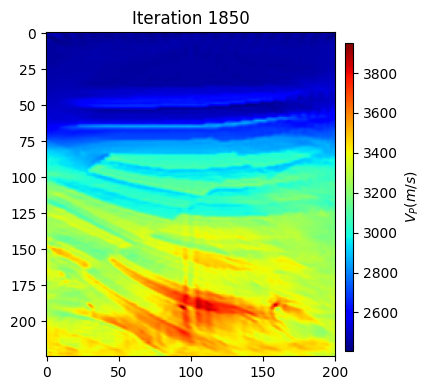

Iteration 1851 ===== loss: 0.0024123436638287137 for data and 91.72984313964844 for model
Iteration 1852 ===== loss: 0.0024199744109951312 for data and 91.70931243896484 for model
Iteration 1853 ===== loss: 0.0024528251406514927 for data and 91.73373413085938 for model
Iteration 1854 ===== loss: 0.0024119209986002673 for data and 91.69712829589844 for model
Iteration 1855 ===== loss: 0.0023931266651267095 for data and 91.8580093383789 for model
Iteration 1856 ===== loss: 0.00247994150655965 for data and 91.36643981933594 for model
Iteration 1857 ===== loss: 0.0024781504180282354 for data and 91.7049331665039 for model
Iteration 1858 ===== loss: 0.002410323026457003 for data and 91.71746063232422 for model
Iteration 1859 ===== loss: 0.0023786069803117286 for data and 91.7043685913086 for model
Iteration 1860 ===== loss: 0.0024152154635105815 for data and 91.74124145507812 for model
Iteration 1861 ===== loss: 0.002450361071775357 for data and 91.86262512207031 for model
Iteration 1862 ==

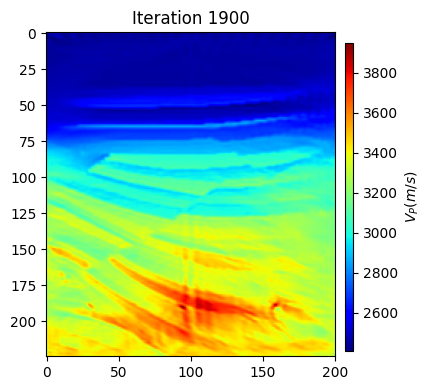

Iteration 1901 ===== loss: 0.0024440085870169456 for data and 91.34516143798828 for model
Iteration 1902 ===== loss: 0.0023591069038957357 for data and 91.41765594482422 for model
Iteration 1903 ===== loss: 0.0024110103425170693 for data and 91.41450500488281 for model
Iteration 1904 ===== loss: 0.0024029605223664214 for data and 91.42314910888672 for model
Iteration 1905 ===== loss: 0.0024406483197318657 for data and 91.54338073730469 for model
Iteration 1906 ===== loss: 0.0024030734119670732 for data and 91.4690933227539 for model
Iteration 1907 ===== loss: 0.00241142138838768 for data and 91.39073944091797 for model
Iteration 1908 ===== loss: 0.0023893227556809073 for data and 91.37626647949219 for model
Iteration 1909 ===== loss: 0.002407947588445885 for data and 91.47606658935547 for model
Iteration 1910 ===== loss: 0.0024071471943032173 for data and 91.41181945800781 for model
Iteration 1911 ===== loss: 0.002409189540360655 for data and 91.45438385009766 for model
Iteration 1912 

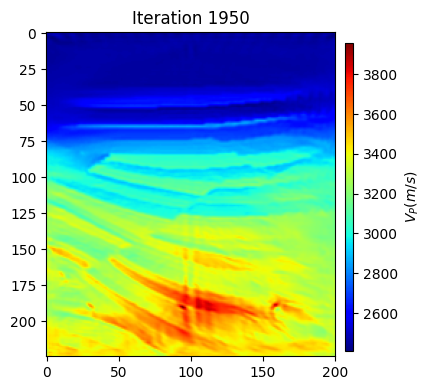

Iteration 1951 ===== loss: 0.0023593175712795485 for data and 91.30423736572266 for model
Iteration 1952 ===== loss: 0.0023791084642566388 for data and 91.31128692626953 for model
Iteration 1953 ===== loss: 0.0023720530637850365 for data and 91.2099380493164 for model
Iteration 1954 ===== loss: 0.0024877212875123534 for data and 91.20003509521484 for model
Iteration 1955 ===== loss: 0.002392478420266083 for data and 91.05558013916016 for model
Iteration 1956 ===== loss: 0.002383005428349688 for data and 91.21258544921875 for model
Iteration 1957 ===== loss: 0.0024198292798939206 for data and 91.1693344116211 for model
Iteration 1958 ===== loss: 0.0024087068270004933 for data and 91.09430694580078 for model
Iteration 1959 ===== loss: 0.0024009787677122013 for data and 91.1412582397461 for model
Iteration 1960 ===== loss: 0.002340240381835472 for data and 91.1958999633789 for model
Iteration 1961 ===== loss: 0.002421604436157005 for data and 90.79017639160156 for model
Iteration 1962 ===

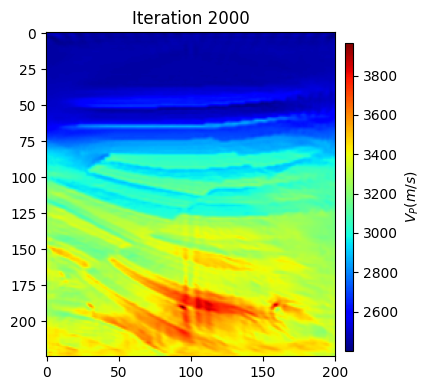

In [11]:
# Cell 11: Build the main network and run first-stage training
# Save one model snapshot every 50 iterations and show it in the notebook

criteria = torch.nn.L1Loss()
autoencoder = Transfomerdecoder(
    batch_size=BATCH_SIZE,
    in_channels=N_SHOTS,
    nt=NT,
    nr=N_RECEIVERS,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    transddepth=TRANSDDEPTH,
    n_blocks_decoder=N_BLOCKS_DECODER,
    final_size_encoder=FINAL_SIZE_ENCODER,
    initial_shape_decoder=DECODER_INITIAL_SHAPE,
    final_spatial_shape=model_shape,
    num_heads=NUM_HEADS,
    mlp_ratio=MPL_RATION,
)
autoencoder = autoencoder.to(device=device)
optim_autoencoder = torch.optim.Adam(autoencoder.parameters(), lr=lr, betas=(0.5, 0.9))

all_loss_data = []
all_loss_model = []
all_loss_prior = []

t_start = time.time()

for iter in range(ITERATION):
    loss_data, m, autoencoder = train_fun(
        Physics=Physics,
        autoencoder=autoencoder,
        d_obs=d_obs,
        optim_autoencoder=optim_autoencoder,
        vp_initial=vp_initial,
        vp_scale=vp_scale,
        criteria=criteria,
        mini_batches=MINI_BATCHES,
        src_loc=source_locations,
        rec_loc=receiver_locations,
        src=source_amplitudes,
        dx=dx,
        dt=dt,
        pml_freq=freq,
    )

    all_loss_data.append(loss_data)
    with torch.no_grad():
        all_loss_model.append(criteria(m, vp_true).item())
    if (iter + 1) % PRINT_FREQ == 0:
        print(f'Iteration {iter + 1} ===== loss: {all_loss_data[-1]} for data and {all_loss_model[-1]} for model')
    if (iter + 1) % SAVE_FREQ == 0:
        np.save(Path / f'model{iter + 1}.npy', m.detach().cpu().T)
        np.save(Path / 'loss.npy', np.asarray(all_loss_data))
        show_result_figure(m, f'Iteration {iter + 1}', Path / f'model{iter + 1}.png')


In [12]:
# Initialize second-stage optimization variables
# If fwi_num_epochs = 0, this cell only prepares the stage-two setup

np.save(Path / 'vel_init_reparameter.npy', m.detach().cpu().numpy())
data = np.load(Path / 'vel_init_reparameter.npy')
model = torch.from_numpy(data).to(device)
model.requires_grad = True
d_model = torch.nn.Parameter(model)

netD = SiameseNetwork(D1)
netD = netD.apply(lambda d_model: weights_init(d_model, leak_value))
netD = netD.to(device)

optim_vel = torch.optim.Adam([{'params': d_model, 'lr': fwi_lr, 'betas': (0.5, 0.99), 'eps': 1e-8, 'weight_decay': 0}])
optim_net = torch.optim.Adam(netD.parameters(), lr=sim_lr, betas=(0.5, 0.99), eps=1e-6, weight_decay=0)

for iter in range(ITERATION, ITERATION + fwi_num_epochs):
    loss_data, optim_vel, optim_net = adjest_fun(
        Physics=Physics,
        netD=netD,
        d_model=d_model,
        d_obs=d_obs,
        mini_batches=MINI_BATCHES,
        optim_vel=optim_vel,
        optim_net=optim_net,
        src_loc=source_locations,
        rec_loc=receiver_locations,
        src=source_amplitudes,
        dx=dx,
        dt=dt,
        pml_freq=freq,
    )

    all_loss_data.append(loss_data)
    ref_model_loss = all_loss_model[-1] if all_loss_model else None
    if (iter + 1) % PRINT_FREQ == 0:
        print(f'Iteration {iter + 1} ===== loss: {all_loss_data[-1]} for data and {ref_model_loss} for model')
    if (iter + 1) % SAVE_FREQ == 0:
        np.save(Path / f'model{iter + 1}.npy', d_model.detach().cpu().T)
        show_result_figure(d_model, f'Iteration {iter + 1}', Path / f'model{iter + 1}.png')


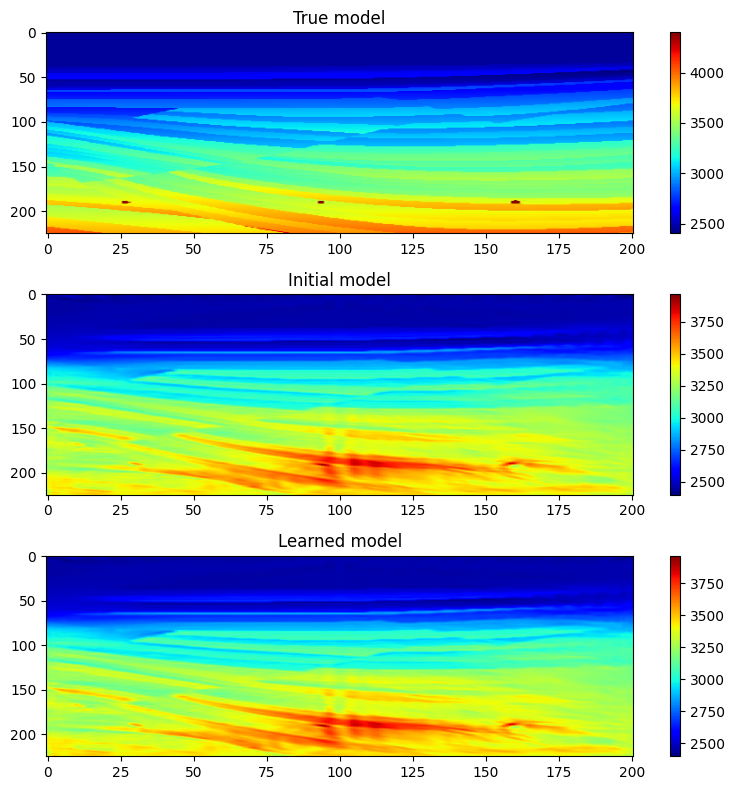

Running complete in 44m  25s


In [13]:
# Save final results, parameters, and comparison plots
# Create the final comparison among the true, stage-one, and learned models

get_dir(Path)
plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.imshow(vp_true.cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('True model')
plt.subplot(3, 1, 2)
plt.imshow(m.detach().cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('Initial model')
plt.subplot(3, 1, 3)
plt.imshow(d_model.detach().cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('Learned model')
plt.tight_layout()
plt.savefig(Path / 'true_initial_learned.png')
plt.show()

np.save(Path / 'all_loss_data.npy', np.asarray(all_loss_data))
np.save(Path / 'all_loss_model.npy', np.asarray(all_loss_model))
np.save(Path / 'd_model.npy', d_model.detach().cpu().numpy())

elapsed_time = time.time() - t_start
params = {
    'Model Shape': {'ny': ny, 'nx': nx, 'dx': dx},
    'Forward Parameters': {
        'n_shots': n_shots,
        'n_sources_per_shot': n_sources_per_shot,
        'd_source': d_source,
        'first_source': first_source,
        'source_depth': source_depth,
        'n_receivers_per_shot': n_receivers_per_shot,
        'dz_receiver': dz_receiver,
        'receiver_depth_start': receiver_depth_start,
        'freq': freq,
        'dt': dt,
        'nt': nt,
        'peak_time': peak_time,
    },
    'Network Parameters': {
        'model_shape': model_shape,
        'BATCH_SIZE': BATCH_SIZE,
        'N_SHOTS': N_SHOTS,
        'NT': NT,
        'N_RECEIVERS': N_RECEIVERS,
        'FINAL_OUT_CHANNEL': FINAL_OUT_CHANNEL,
        'N_BLOCKS_DECODER': N_BLOCKS_DECODER,
        'NUM_HEADS': NUM_HEADS,
        'MPL_RATION': MPL_RATION,
        'PATCH_SIZE': PATCH_SIZE,
        'EMBED_DIM': EMBED_DIM,
        'TRANSDDEPTH': TRANSDDEPTH,
    },
    'Run Parameters': {
        'vp_scale': vp_scale,
        'LR_MILESTONE': LR_MILESTONE,
        'ITERATION': ITERATION,
        'lr': lr,
        'MINI_BATCHES': MINI_BATCHES,
        'LAM_PRIOR': LAM_PRIOR,
        'PRINT_FREQ': PRINT_FREQ,
        'SAVE_FREQ': SAVE_FREQ,
    },
    'adjest parameters': {
        'fwi_lr': fwi_lr,
        'fwi_batch': fwi_batch,
        'fwi_num_epochs': fwi_num_epochs,
        'sim_lr': sim_lr,
    },
    'loss': {
        'loss_data': all_loss_data[-1] if all_loss_data else None,
    },
    'time': {
        'Running complete in': elapsed_time,
    },
}

save_run_parameters(Path / 'parameters.txt', params)
print('Running complete in {:.0f}m  {:.0f}s'.format(elapsed_time // 60, elapsed_time % 60))
